# Regressione multipla



La **regressione multipla** è un modello statistico che permette di prevedere una variabile dipendente $y$ in funzione di più variabili indipendenti $x_1, x_2, \dots, x_n$. L'equazione generale è:  

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n + \epsilon
$$  

dove $\beta_0$ è l'intercetta, $\beta_i$ i coefficienti delle variabili indipendenti e $\epsilon$ l'errore residuo.

Nel machine learning, la regressione multipla costituisce un ponte tra modelli predittivi interpretabili e approcci più complessi, introducendo l'uso di più feature per migliorare la precisione delle previsioni.

## Il prezzo delle macchine

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('cars.xlsx')
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


Come prima cosa, selezioniamo le features che ci interessano. Facciamo l'ipotesi che l'ufficio vendite sia giunto alla conclusione che le caratteristiche più importanti per la determinazione del prezzo sono:

* Mileage (km percorsi)
* Cylinder (numero di cilindri)
* Numero di porte (doors)

Non che le altre non influiscano (influiscono, eccome), però come dicevamo nei modelli abbiamo sempre un trade-off tra performance e semplicità, quindi questo genere di considerazioni aiutano a rendere il modello semplice ed efficiente.

In più, possono esserci delle variabili latenti. Il numero di porte di una macchina potrebbe essere legato al fatto che l'auto è sportiva, quindi avere determinate caratteristiche del motore, essere associato ad un certo status, ad una certa percezione e così via. Potrebbe essere una variabile molto più importante di quello che sembra a prima vista.

In [2]:
from sklearn.linear_model import LinearRegression

features = ['Mileage', 'Cylinder', 'Doors']

X = df[features]
y = df['Price']

Per la regressione polinomiale, utilizzeremo `scikit-learn`, che vedremo più in dettaglio nella prossima lezione. Con **scikit-learn**, i modelli si addestrano e si usano per fare previsioni con due metodi semplici e intuitivi:  

- **`fit()`**: addestra il modello con i dati forniti (es. `modello.fit(X, y)` per classificazione o regressione).  
- **`predict()`**: genera previsioni sui nuovi dati (es. `y_pred = modello.predict(X_new)`).  

In [3]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

Nel nostro modello la formula è la seguente:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3
$$

ricordando che $\beta_0$ è detta *intercetta* e i $\beta_m$ con $m=1...n$ sono detti *coefficienti*. Tenendo conto delle caratteristiche che abbiamo utilizzato, possiamo scrivere nel nostro caso la formula come:

$$
\operatorname{Price} = \beta_0 + \beta_1 \cdot \operatorname{Mileage} + \beta_2 \cdot \operatorname{Cylinder} + \beta_3 \cdot \operatorname{Doors}
$$


In [4]:
from sklearn.metrics import r2_score

# Posso andare a recuperare i parametri del modello nel seguente modo:

B0 = model.intercept_
Bn = model.coef_
R2 = r2_score(y, y_pred)

print('Intercetta:',B0)
for i in range(len(features)):
  print(f'{features[i]} (B{i+1}):',Bn[i])

print('R2 score:',R2)


Intercetta: 9025.216308461173
Mileage (B1): -0.15532986443532562
Cylinder (B2): 4029.404859235798
Doors (B3): -1653.1135524003669
R2 score: 0.3600299189649302


A quanto pare, come prevedibile, il numero di km percorsi ha un'influenza negativa sul prezzo. Così come un elevato numero di cilindri. Anche il numero di porte ha un'influenza negativa, probabilmente per i motivi indicati sopra.

Facciamo un test, con dei dati fabbricati. Nota bene: il modello è stato addestrato su di un dataframe, quindi deve ricevere in ingresso un dataframe, per quanto contenente 1 singolo valore.

In [5]:
fake_car = {
    'Mileage': [45000],
    'Cylinder': [8],
    'Doors': [4]
}

test_df = pd.DataFrame(fake_car)
print(test_df)
predicted = model.predict(test_df)
print(predicted)

   Mileage  Cylinder  Doors
0    45000         8      4
[27658.15707316]


Facciamo alcune verifiche di quanto riportato. Ci serviamo della funzione `groupby` di pandas, che è una funzione estremamente complessa che permette di suddividere un DataFrame in gruppi basati su una o più colonne, eseguire operazioni aggreganti come somma, media, conteggio, e altre trasformazioni, e infine combinare i risultati in un nuovo DataFrame, facilitando l'analisi di dati categoriali o per segmenti.

E' una funzione estremamente complessa, di cui puoi trovare diversi tutorial dedicati. Ci limiteremo ad un utilizzo di base, con il metodo `mean`, che consente di calcolare la media di ciascun gruppo, aggregando i dati in base a una o più colonne. Questo è utile, ad esempio, per ottenere una panoramica statistica di un dataset, come calcolare la media delle vendite per ciascun mese o la media del punteggio di test per ogni studente in un gruppo.

In [6]:
aggregate_doors = df.groupby(['Doors'])
aggregate_doors['Price'].mean()

Doors
2    23807.135520
4    20580.670749
Name: Price, dtype: float64

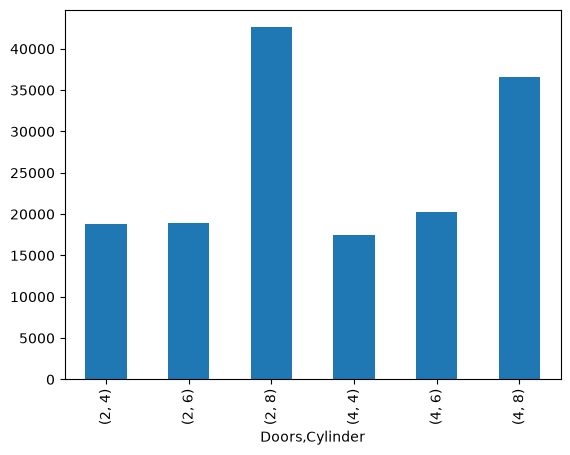

In [7]:
aggregate_doors_cyl = df.groupby(['Doors','Cylinder'])['Price'].mean()
aggregate_doors_cyl.plot(kind='bar')
plt.show()

Utilizziamo la funzione `pd.cut` per suddividere una variabile continua in intervalli (o bin), consentendo di trasformare i dati numerici in categorie discrete. Questo è particolarmente utile quando vogliamo raggruppare i dati in classi, come ad esempio suddividere le età in fasce (ad esempio, 0-18, 19-35, 36-50, ecc.) o segmentare una variabile come il reddito in intervalli di guadagno.

In [8]:
import matplotlib.pyplot as plt

bins =  np.arange(0,50000,10000)
my_ranges=pd.cut(df['Mileage'],bins)

my_ranges

0          (0, 10000]
1          (0, 10000]
2      (10000, 20000]
3      (10000, 20000]
4      (10000, 20000]
            ...      
799    (10000, 20000]
800    (10000, 20000]
801    (20000, 30000]
802    (20000, 30000]
803    (30000, 40000]
Name: Mileage, Length: 804, dtype: category
Categories (4, interval[int64, right]): [(0, 10000] < (10000, 20000] < (20000, 30000] < (30000, 40000]]

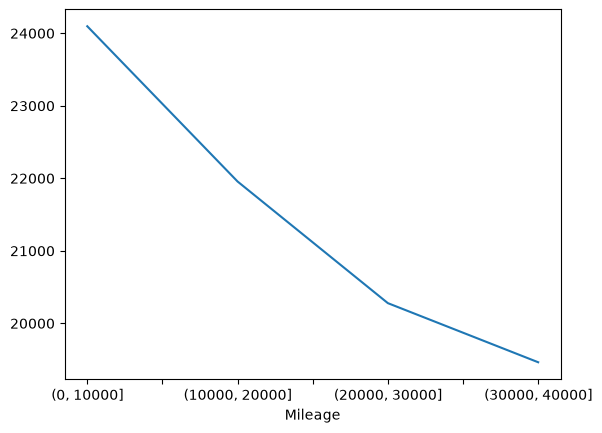

In [9]:
groups = df['Price'].groupby(my_ranges, observed=True).mean()
groups.plot.line()
plt.show()

# Attività

Prova a creare nuovamente il modello utilizzando differenti `features`. Prova a fare alcune considerazioni preventivamente analizzando un po' come variano i valori aggregati.

In [10]:
pivot = pd.pivot_table(df, values='Price', index=['Make','Model'], columns='Cylinder', aggfunc='mean')
pivot

Cylinder                          4             6             8
Make      Model                                                
Buick     Century               NaN  15989.528107           NaN
          Lacrosse              NaN  21077.860162           NaN
          Lesabre               NaN  19633.447769           NaN
          Park Avenue           NaN  24015.453468           NaN
Cadillac  CST-V                 NaN           NaN  45022.924436
          CTS                   NaN  30455.144774           NaN
          Deville               NaN           NaN  36238.281772
          STS-V6                NaN  37374.584290           NaN
          STS-V8                NaN           NaN  42984.448195
          XLR-V8                NaN           NaN  62938.736572
Chevrolet AVEO         10752.833305           NaN           NaN
          Cavalier     12865.913327           NaN           NaN
          Classic      13597.916169           NaN           NaN
          Cobalt       13952.927593           NaN           NaN
          Corvette              NaN           NaN  39155.712375
          Impala                NaN  19923.092805           NaN
          Malibu                NaN  17166.928256           NaN
          Monte Carlo           NaN  19841.957500           NaN
Pontiac   Bonneville            NaN  20055.657440  22577.805480
          G6                    NaN  19652.267843           NaN
          GTO                   NaN           NaN  29130.247052
          Grand Am     14921.325181  16238.093335           NaN
          Grand Prix            NaN  17890.346792           NaN
          Sunfire      12582.986048           NaN           NaN
          Vibe         15881.386094           NaN           NaN
SAAB      9-2X AWD     24960.948265           NaN           NaN
          9_3          29047.756011           NaN           NaN
          9_3 HO       30429.581085           NaN           NaN
          9_5          30023.924244           NaN           NaN
          9_5 HO       28184.822515           NaN           NaN
Saturn    Ion          13464.383830           NaN           NaN
          L Series              NaN  16550.926211           NaN

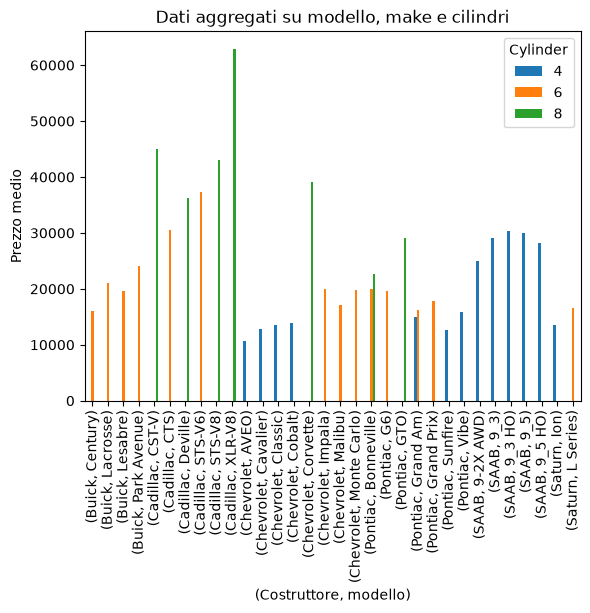

In [11]:
pivot.plot.bar()
plt.title('Dati aggregati su modello, make e cilindri')
plt.ylabel('Prezzo medio')
plt.xlabel('(Costruttore, modello)')
plt.show()